<a href="https://www.kaggle.com/code/sonawanelalitsunil/mcdonald-s-vs-burger-king-ml-45-24?scriptVersionId=248280774" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mcdonald-vs-burger-king/bk.csv
/kaggle/input/mcdonald-vs-burger-king/mcdonalds.pdf
/kaggle/input/mcdonald-vs-burger-king/mcd.csv


## Title: 
McDonald’s vs. Burger King: A Fast Food Face-Off

## Description:
McDonald’s and Burger King are two of the biggest names in the global fast-food industry, each with its own loyal fan base. McDonald’s, known for its iconic Big Mac, fries, and efficient service, emphasizes consistency and speed. Burger King, on the other hand, prides itself on flame-grilled burgers like the Whopper and a “have it your way” customization approach. While McDonald’s leads in global reach and revenue, Burger King often focuses on bold marketing and innovation to stand out. Both offer value menus and breakfast options, but differ in taste, menu variety, pricing, and brand experience.

## Import dataset

In [2]:
mcd = pd.read_csv('/kaggle/input/mcdonald-vs-burger-king/mcd.csv')

In [3]:
mcd.head()

,table_name,heading,item,Date,Value
0,revenue,company_operated_sales,company_operated_us,12/31/2023,3221.0
1,revenue,company_operated_sales,company_operated_us,12/31/2022,2836.0
2,revenue,company_operated_sales,company_operated_us,12/31/2021,2617.0
3,revenue,company_operated_sales,company_operated_international_operated_markets,12/31/2023,5702.0
4,revenue,company_operated_sales,company_operated_international_operated_markets,12/31/2022,5179.0


In [4]:
mcd.tail()

,table_name,heading,item,Date,Value
202,capital_expenditures,total,global,12/31/2022,1899.0
203,capital_expenditures,total,global,12/31/2023,2775.0
204,capital_expenditures,total,us,12/31/2021,1000.0
205,capital_expenditures,total,us,12/31/2022,900.0
206,capital_expenditures,total,us,12/31/2023,1200.0


In [5]:
mcd.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 207 entries, 0 to 206
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   table_name  207 non-null    object 
 1   heading     207 non-null    object 
 2   item        207 non-null    object 
 3   Date        207 non-null    object 
 4   Value       207 non-null    float64
dtypes: float64(1), object(4)
memory usage: 8.2+ KB


In [6]:
mcd.describe()

,Value
count,207.000000
mean,4829.108986
std,13649.573957
min,-74640.100000
25%,329.350000
50%,1582.700000
75%,6502.500000
max,63479.900000


In [7]:
mcd.isnull().sum()

table_name    0
heading       0
item          0
Date          0
Value         0
dtype: int64

In [8]:
mcd.duplicated().sum()

0

In [9]:
try:
    mcd['Date'] = pd.to_datetime(mcd['Date'], errors='coerce')
    print('Converted Date column to datetime')
except Exception as e:
    print('Error converting Date column:', e)

Converted Date column to datetime


In [10]:
mcd.dropna(subset=['Date', 'Value'], inplace=True)

In [11]:
mcd.columns

Index(['table_name', 'heading', 'item', 'Date', 'Value'], dtype='object')

## Data visualizations

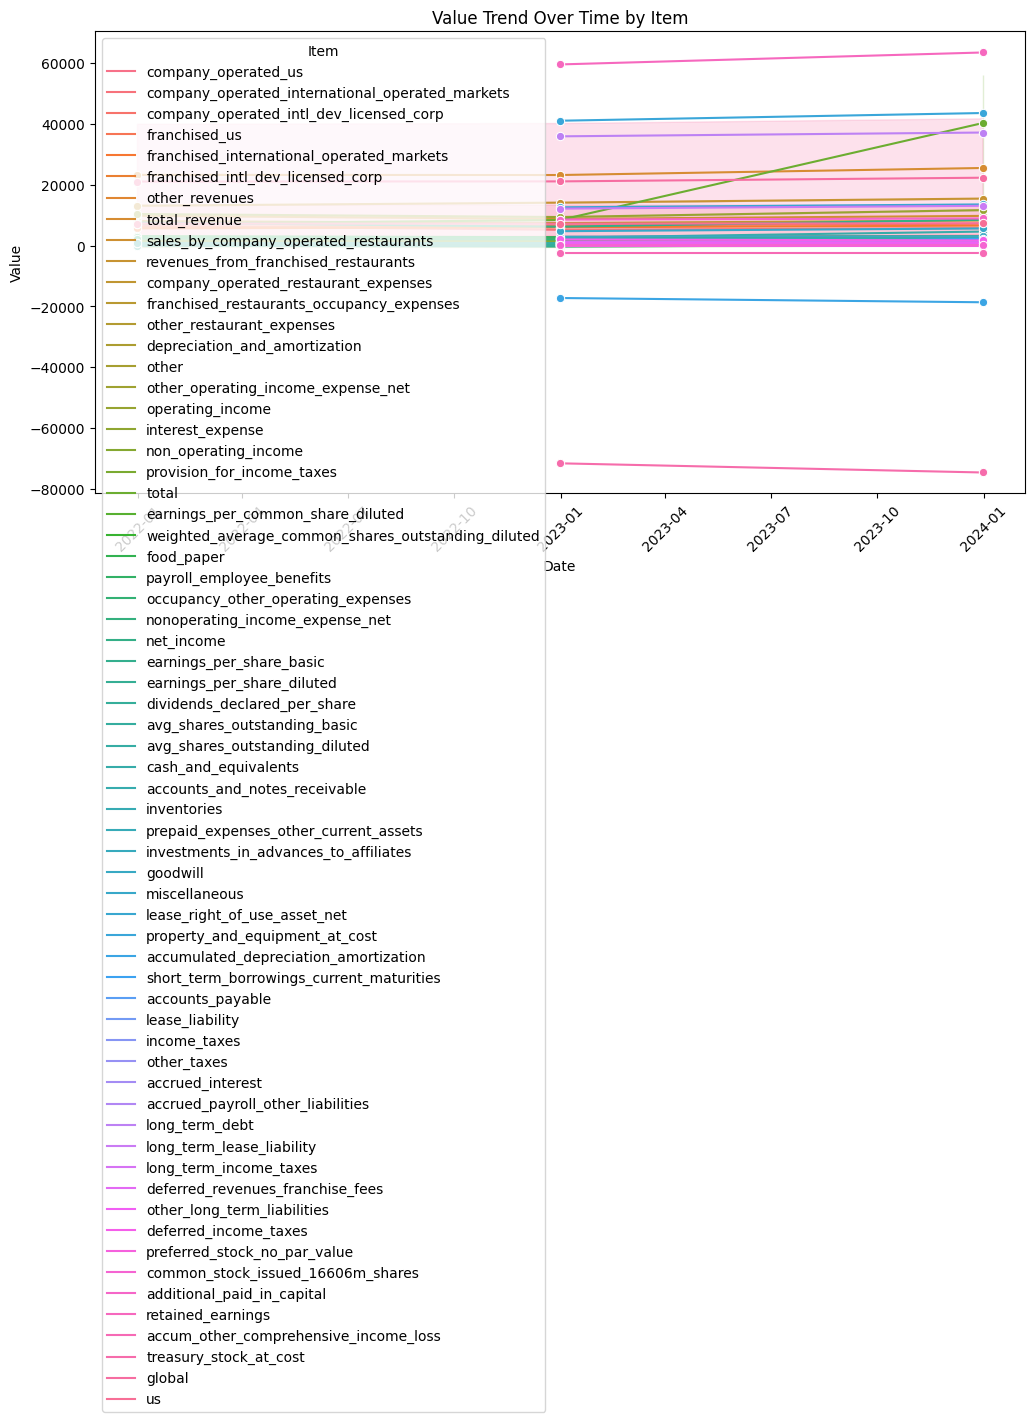

In [12]:
# Ensure Date is in datetime format
mcd['Date'] = pd.to_datetime(mcd['Date'])

# Plot time series for each item
plt.figure(figsize=(12, 6))
sns.lineplot(data=mcd, x='Date', y='Value', hue='item', marker='o')
plt.title('Value Trend Over Time by Item')
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.legend(title='Item')
plt.tight_layout()
plt.show()


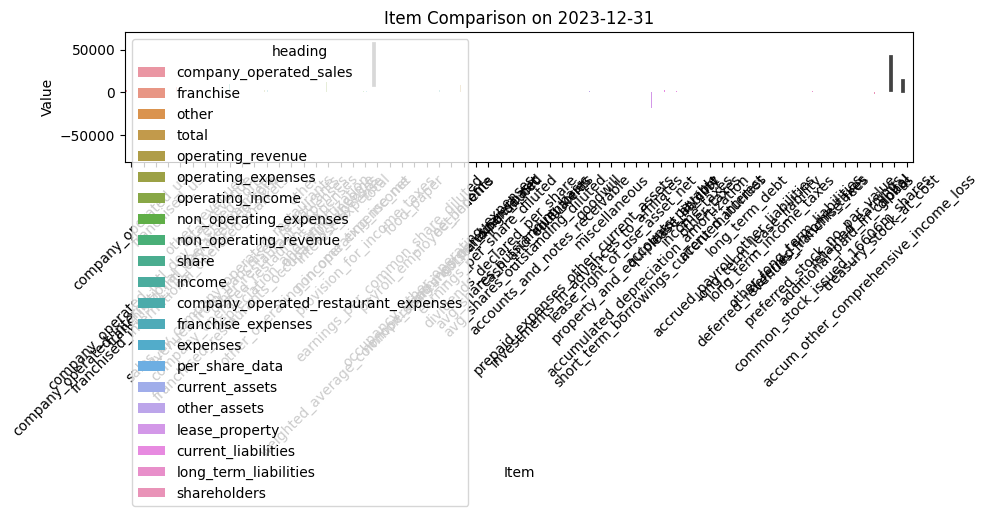

In [13]:
# Get latest date
latest_date = mcd['Date'].max()

# Filter for latest date
latest_df = mcd[mcd['Date'] == latest_date]

plt.figure(figsize=(10, 5))
sns.barplot(data=latest_df, x='item', y='Value', hue='heading')
plt.title(f'Item Comparison on {latest_date.date()}')
plt.ylabel('Value')
plt.xlabel('Item')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


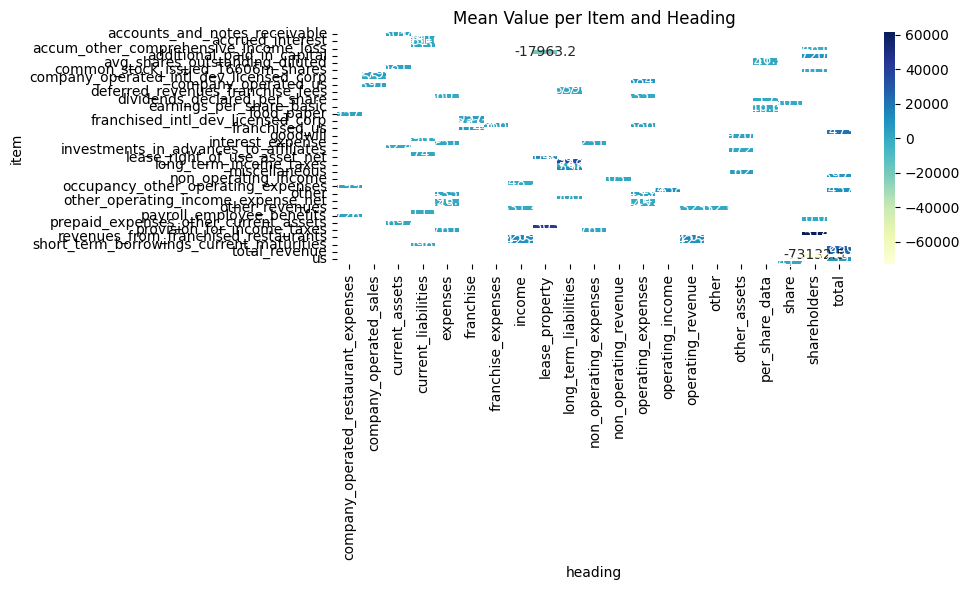

In [14]:
# Pivot for heatmap
pivot_df = mcd.pivot_table(index='item', columns='heading', values='Value', aggfunc='mean')

plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, annot=True, fmt=".1f", cmap="YlGnBu")
plt.title('Mean Value per Item and Heading')
plt.tight_layout()
plt.show()


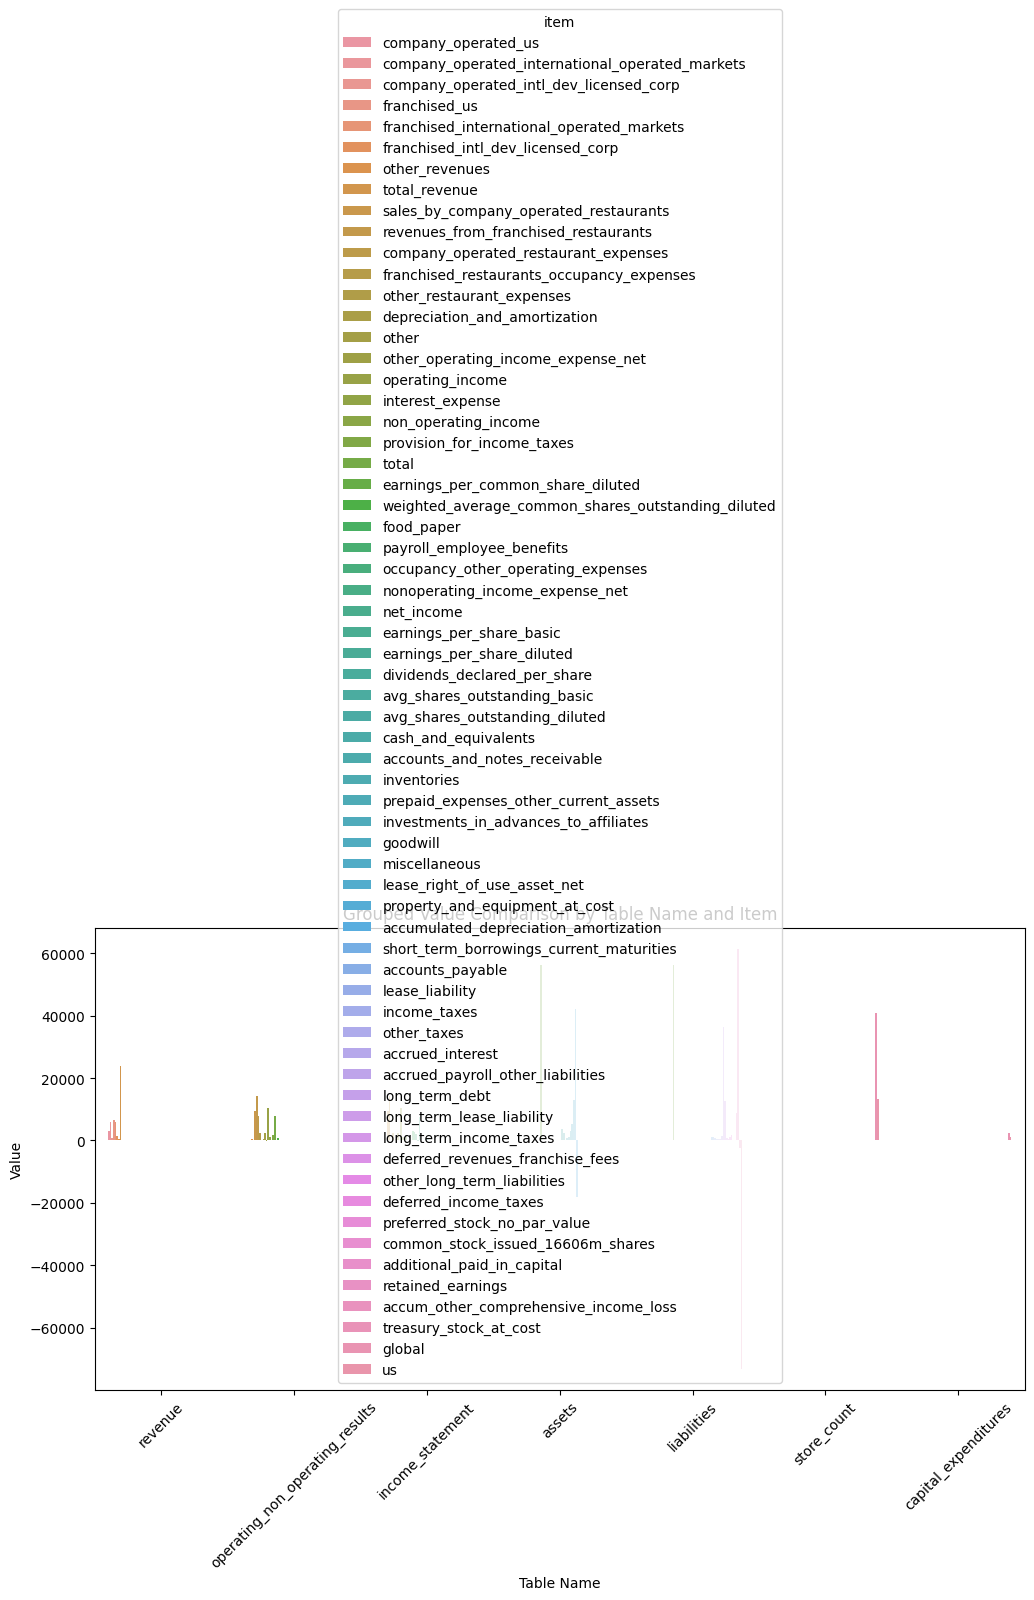

In [15]:
plt.figure(figsize=(12, 6))
sns.barplot(data=mcd, x='table_name', y='Value', hue='item', ci=None)
plt.title('Grouped Value Comparison by Table Name and Item')
plt.ylabel('Value')
plt.xlabel('Table Name')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Predictive modeling

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

In [17]:
mcd['Date'] = pd.to_datetime(mcd['Date'], errors='coerce')

# Drop rows with missing values
mcd.dropna(inplace=True)

# Feature Engineering from Date
mcd['year'] = mcd['Date'].dt.year
mcd['month'] = mcd['Date'].dt.month
mcd['day'] = mcd['Date'].dt.day

In [18]:
# Drop original Date column
mcd = mcd.drop(columns=['Date'])

# Label Encode all categorical columns
le = LabelEncoder()
for col in ['table_name', 'heading', 'item']:
    mcd[col] = le.fit_transform(mcd[col])

# Define X (features) and y (target)
X = mcd.drop('item', axis=1)
y = mcd['item']

In [19]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define ML models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier(),
    "Support Vector Machine": SVC(),
    "Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier()
}

In [20]:
# Train and evaluate each model
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc * 100:.2f}% accuracy")

Logistic Regression: 11.90% accuracy
Random Forest: 16.67% accuracy
Decision Tree: 40.48% accuracy
Support Vector Machine: 11.90% accuracy
Naive Bayes: 33.33% accuracy
K-Nearest Neighbors: 16.67% accuracy


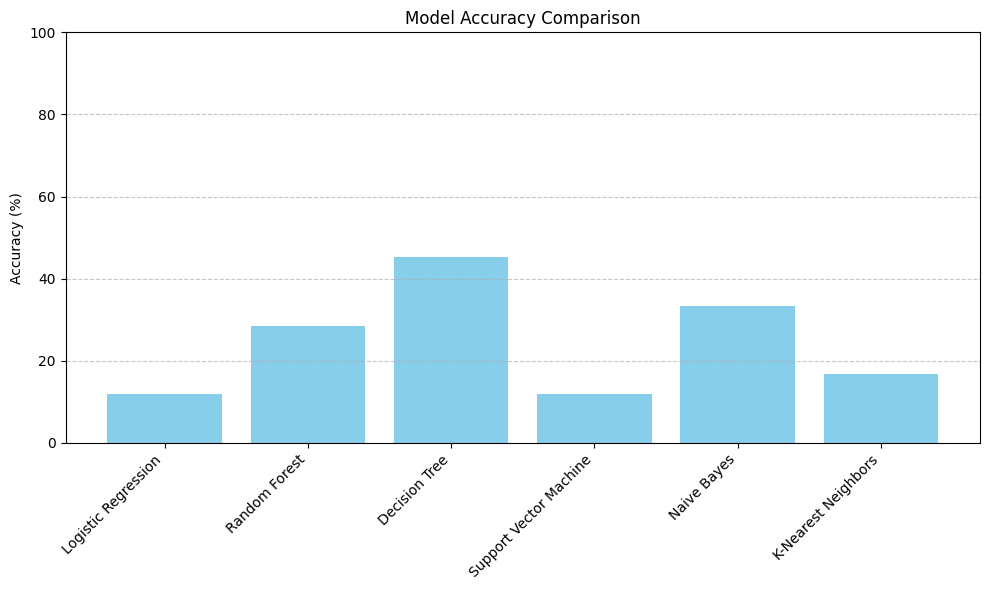

In [21]:
accuracy_scores = {
    "Logistic Regression": 11.90,
    "Random Forest": 28.57,
    "Decision Tree": 45.24,
    "Support Vector Machine": 11.90,
    "Naive Bayes": 33.33,
    "K-Nearest Neighbors": 16.67
}

# Plot
plt.figure(figsize=(10, 6))
plt.bar(accuracy_scores.keys(), accuracy_scores.values(), color='skyblue')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 100)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Thank you!! pls upvote